In [4]:
pip install matplotlib

  Using cached matplotlib-3.9.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.2.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.53.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (162 kB)
  Using cached kiwisolver-1.4.5-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.4 kB)
  Using cached pillow-10.4.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (9.2 kB)
  Using cached pyparsing-3.1.2-py3-none-any.whl.metadata (5.1 kB)
Using cached matplotlib-3.9.1-cp312-cp312-macosx_11_0_arm64.whl (7.8 MB)
Using cached contourpy-1.2.1-cp312-cp312-macosx_11_0_arm64.whl (245 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.53.1-cp312-cp312-macosx_11_0_arm64.whl (2.2 MB)
Using cached kiwisolver-1.4.5-cp312-cp312-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-10.4.0-cp312-cp312-macosx_11_0_arm64.whl (3.4 MB)
Using cached pyparsing-3.1.2-py3-none-any.

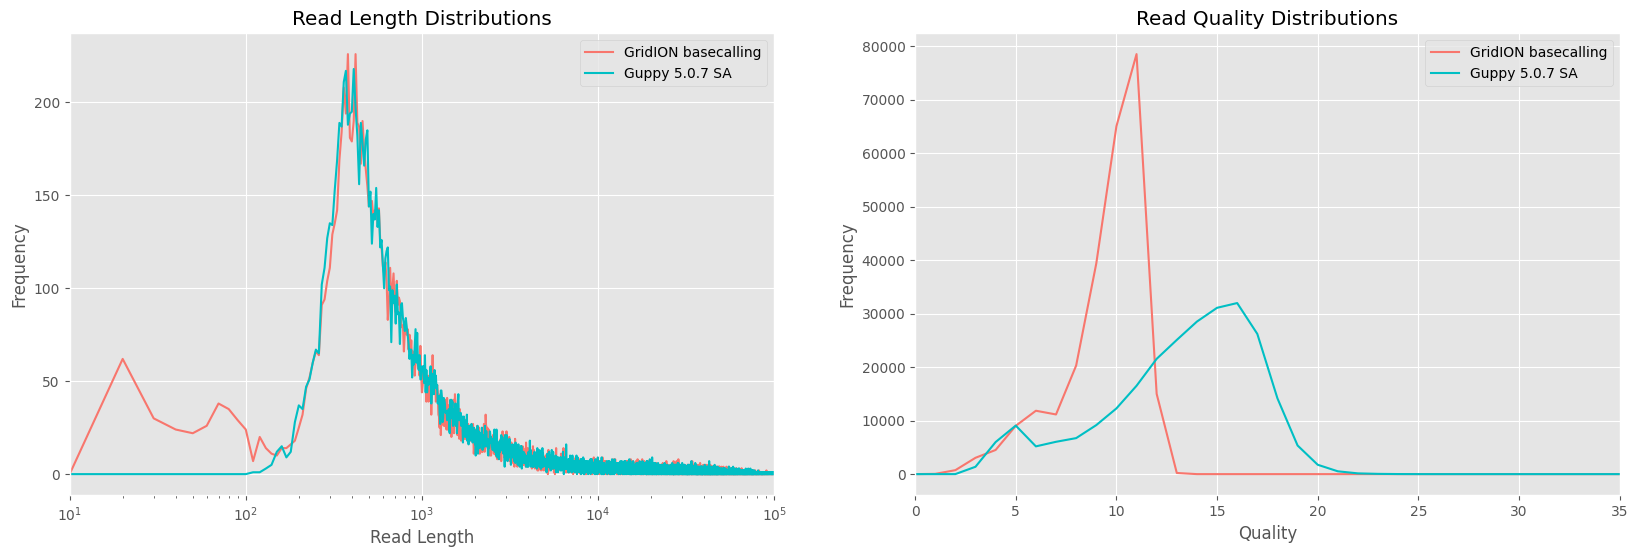

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
plt.style.use('ggplot')

colours = ["#F8766D","#00BFC4","#7CAE00","#C77CFF"]

GA20000_all_reads_hist = pd.read_csv("./data/ATRun1/hists/bins.txt", delimiter='\t')
GA20000_quality_hist = pd.read_csv("./data/ATRun1/hists/all_reads.fq.readquality.txt", delimiter='\t', names=["val","freq"])
guppy_507_all_reads_hist = pd.read_csv("./data/ATRun1/hists_guppy507/bins.txt", delimiter='\t')
guppy_507_quality_hist = pd.read_csv("./data/ATRun1/hists_guppy507/all_reads.fq.readquality.txt", delimiter='\t', names=["val","freq"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,6))


ax1.plot(GA20000_all_reads_hist["bin"], GA20000_all_reads_hist["freq"], label="GridION basecalling", color=colours[0])
ax1.plot(guppy_507_all_reads_hist["bin"], guppy_507_all_reads_hist["freq"], label="Guppy 5.0.7 SA", color=colours[1])
ax1.set_ylabel("Frequency")
ax1.set_xlabel("Read Length")
ax1.set_title("Read Length Distributions")
ax1.legend()
ax1.set_xscale('log')
ax1.set_xlim(10,100000)

ax2.plot(GA20000_quality_hist["val"],GA20000_quality_hist["freq"], label="GridION basecalling", color=colours[0])
ax2.plot(guppy_507_quality_hist["val"], guppy_507_quality_hist["freq"], label="Guppy 5.0.7 SA", color=colours[1])
ax2.set_ylabel("Frequency")
ax2.set_xlabel("Quality")
ax2.set_title("Read Quality Distributions")
ax2.set_xlim(0,35)
ax2.legend()

fig.savefig("plots/ATRun1_dists.pdf", bbox_inches='tight')

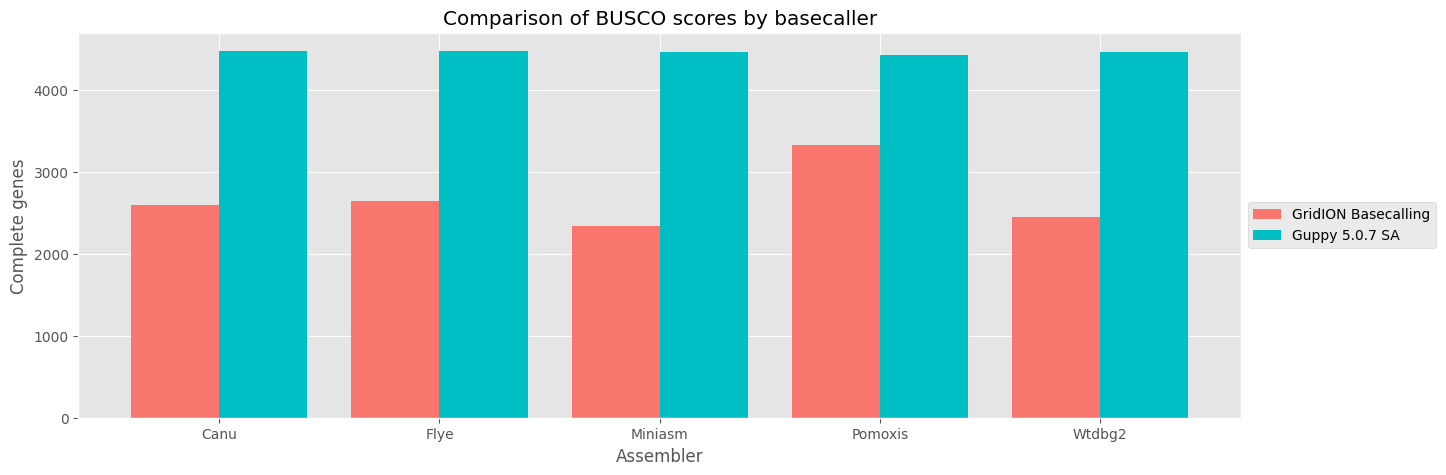

In [15]:
busco = pd.read_csv("./data/ATRun1/busco_comparison.csv")
colours = ["#F8766D","#00BFC4"]
fig = plt.figure(figsize=(15,5))
ax = fig.add_subplot(111)

x = np.arange(len(busco["Assembler"]))
ax.bar(x-0.2, busco["GridION"], width=0.4, align='center', label="GridION Basecalling", color=colours[0])
ax.bar(x+0.2, busco["Guppy SA"], width=0.4, align='center', label="Guppy 5.0.7 SA", color=colours[1])

ax.set_ylabel('Complete genes')
ax.set_xlabel('Assembler')
ax.set_title('Comparison of BUSCO scores by basecaller')
ax.set_xticks(x)
ax.set_xticklabels(busco["Assembler"])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.savefig("plots/BUSCO.pdf", bbox_inches='tight')

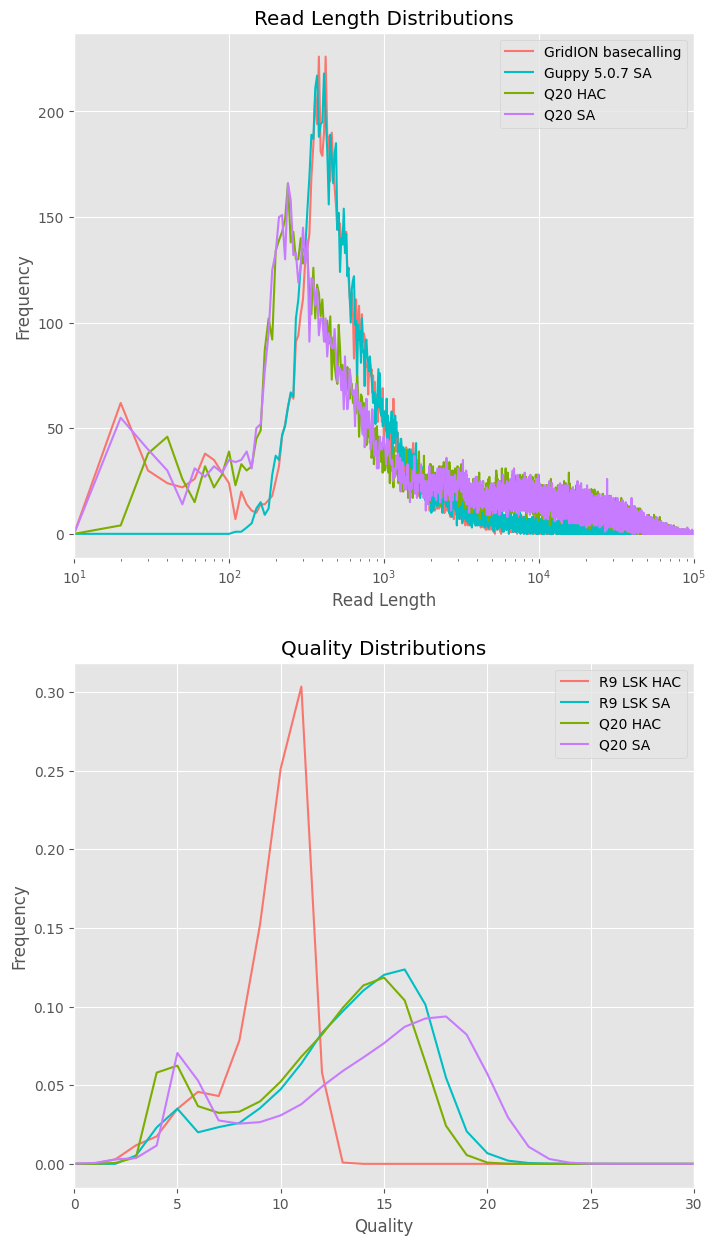

In [14]:
colours = ["#F8766D","#00BFC4","#7CAE00","#C77CFF"]

GA20000_all_reads_hist = pd.read_csv("./data/ATRun1/hists/bins.txt", delimiter='\t')
GA20000_quality_hist = pd.read_csv("./data/ATRun1/hists/all_reads.fq.readquality.txt", delimiter='\t', names=["val","freq"])
guppy_507_all_reads_hist = pd.read_csv("./data/ATRun1/hists_guppy507/bins.txt", delimiter='\t')
guppy_507_quality_hist = pd.read_csv("./data/ATRun1/hists_guppy507/all_reads.fq.readquality.txt", delimiter='\t', names=["val","freq"])

Q20_all_reads_hist = pd.read_csv("./data/ATRun2/hists/bins.txt", delimiter='\t')
Q20_quality_hist = pd.read_csv("./data/ATRun2/hists/all_reads.readquality.txt", delimiter='\t', names=["val","freq"])
Q20_SA_all_reads_hist = pd.read_csv("./data/ATRun2/hists_guppy5016/bins.txt", delimiter='\t')
Q20_SA_quality_hist = pd.read_csv("./data/ATRun2/hists_guppy5016/all_reads.readquality.txt", delimiter='\t', names=["val","freq"])

GA2000_sum = GA20000_quality_hist["freq"].sum()
guppy_507_sum = guppy_507_quality_hist["freq"].sum()
Q20_sum = Q20_quality_hist["freq"].sum()
Q20_SA_sum = Q20_SA_quality_hist["freq"].sum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,15))

ax1.plot(GA20000_all_reads_hist["bin"], GA20000_all_reads_hist["freq"], label="GridION basecalling", color=colours[0])
ax1.plot(guppy_507_all_reads_hist["bin"], guppy_507_all_reads_hist["freq"], label="Guppy 5.0.7 SA", color=colours[1])
ax1.plot(Q20_all_reads_hist["bin"], Q20_all_reads_hist["freq"], label="Q20 HAC", color=colours[2])
ax1.plot(Q20_SA_all_reads_hist["bin"], Q20_SA_all_reads_hist["freq"], label="Q20 SA", color=colours[3])
ax1.set_ylabel("Frequency")
ax1.set_xlabel("Read Length")
ax1.set_title("Read Length Distributions")
ax1.legend()
ax1.set_xscale('log')
ax1.set_xlim(10,100000)

ax2.plot(GA20000_quality_hist["val"], GA20000_quality_hist["freq"]/GA2000_sum, label="R9 LSK HAC", color=colours[0])
ax2.plot(guppy_507_quality_hist["val"], guppy_507_quality_hist["freq"]/guppy_507_sum, label="R9 LSK SA", color=colours[1])
ax2.plot(Q20_quality_hist["val"], Q20_quality_hist["freq"]/Q20_sum, label="Q20 HAC", color=colours[2])
ax2.plot(Q20_SA_quality_hist["val"], Q20_SA_quality_hist["freq"]/Q20_SA_sum, label="Q20 SA", color=colours[3])
ax2.set_ylabel("Frequency")
ax2.set_xlabel("Quality")
ax2.set_title("Quality Distributions")
ax2.set_xlim(0,30)
ax2.legend()

fig.savefig("plots/all_dists_new.pdf", bbox_inches='tight')

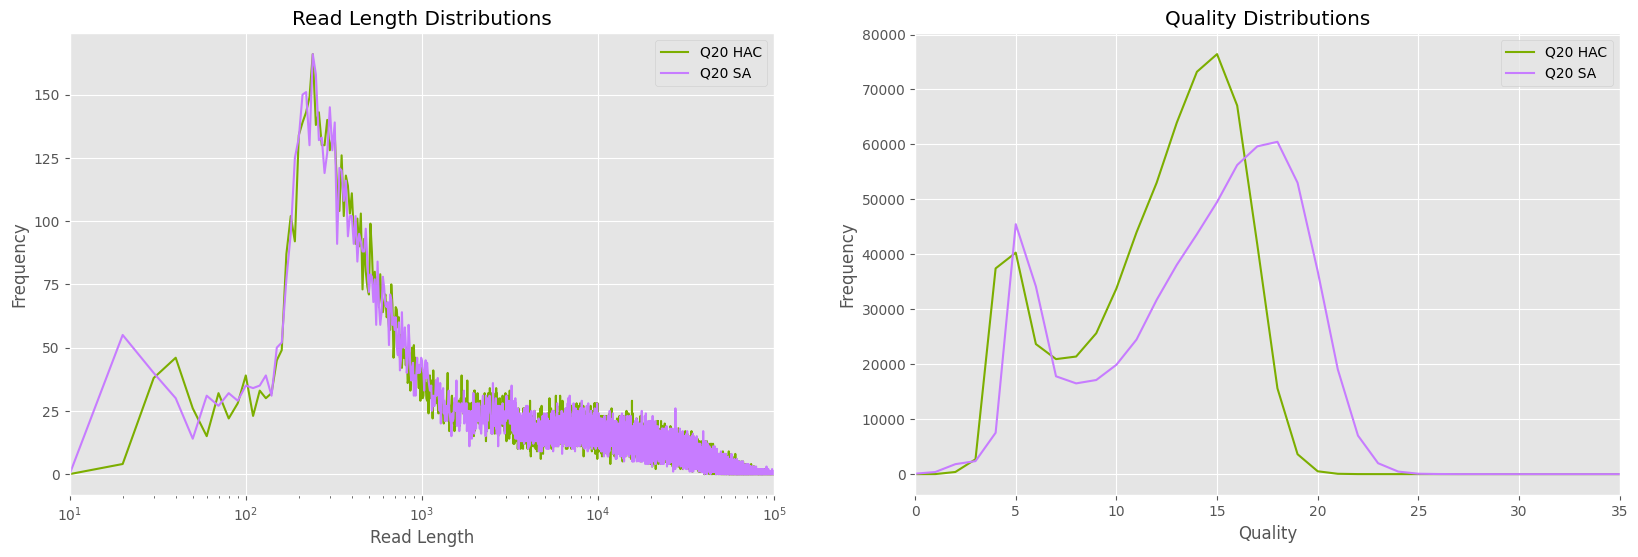

In [6]:
colours = ["#F8766D","#00BFC4","#7CAE00","#C77CFF"]

Q20_all_reads_hist = pd.read_csv("./data/ATRun2/hists/bins.txt", delimiter='\t')
Q20_quality_hist = pd.read_csv("./data/ATRun2/hists/all_reads.readquality.txt", delimiter='\t', names=["val","freq"])
Q20_SA_all_reads_hist = pd.read_csv("./data/ATRun2/hists_guppy5016/bins.txt", delimiter='\t')
Q20_SA_quality_hist = pd.read_csv("./data/ATRun2/hists_guppy5016/all_reads.readquality.txt", delimiter='\t', names=["val","freq"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,6))

ax1.plot(Q20_all_reads_hist["bin"], Q20_all_reads_hist["freq"], label="Q20 HAC", color=colours[2])
ax1.plot(Q20_SA_all_reads_hist["bin"], Q20_SA_all_reads_hist["freq"], label="Q20 SA", color=colours[3])
ax1.set_ylabel("Frequency")
ax1.set_xlabel("Read Length")
ax1.set_title("Read Length Distributions")
ax1.legend()
ax1.set_xscale('log')
ax1.set_xlim(10,100000)


ax2.plot(Q20_quality_hist["val"], Q20_quality_hist["freq"], label="Q20 HAC", color=colours[2])
ax2.plot(Q20_SA_quality_hist["val"], Q20_SA_quality_hist["freq"], label="Q20 SA", color=colours[3])
ax2.set_ylabel("Frequency")
ax2.set_xlabel("Quality")
ax2.set_title("Quality Distributions")
ax2.set_xlim(0,35)
ax2.legend()

fig.savefig("plots/ATRun2_dists_new.pdf", bbox_inches='tight')

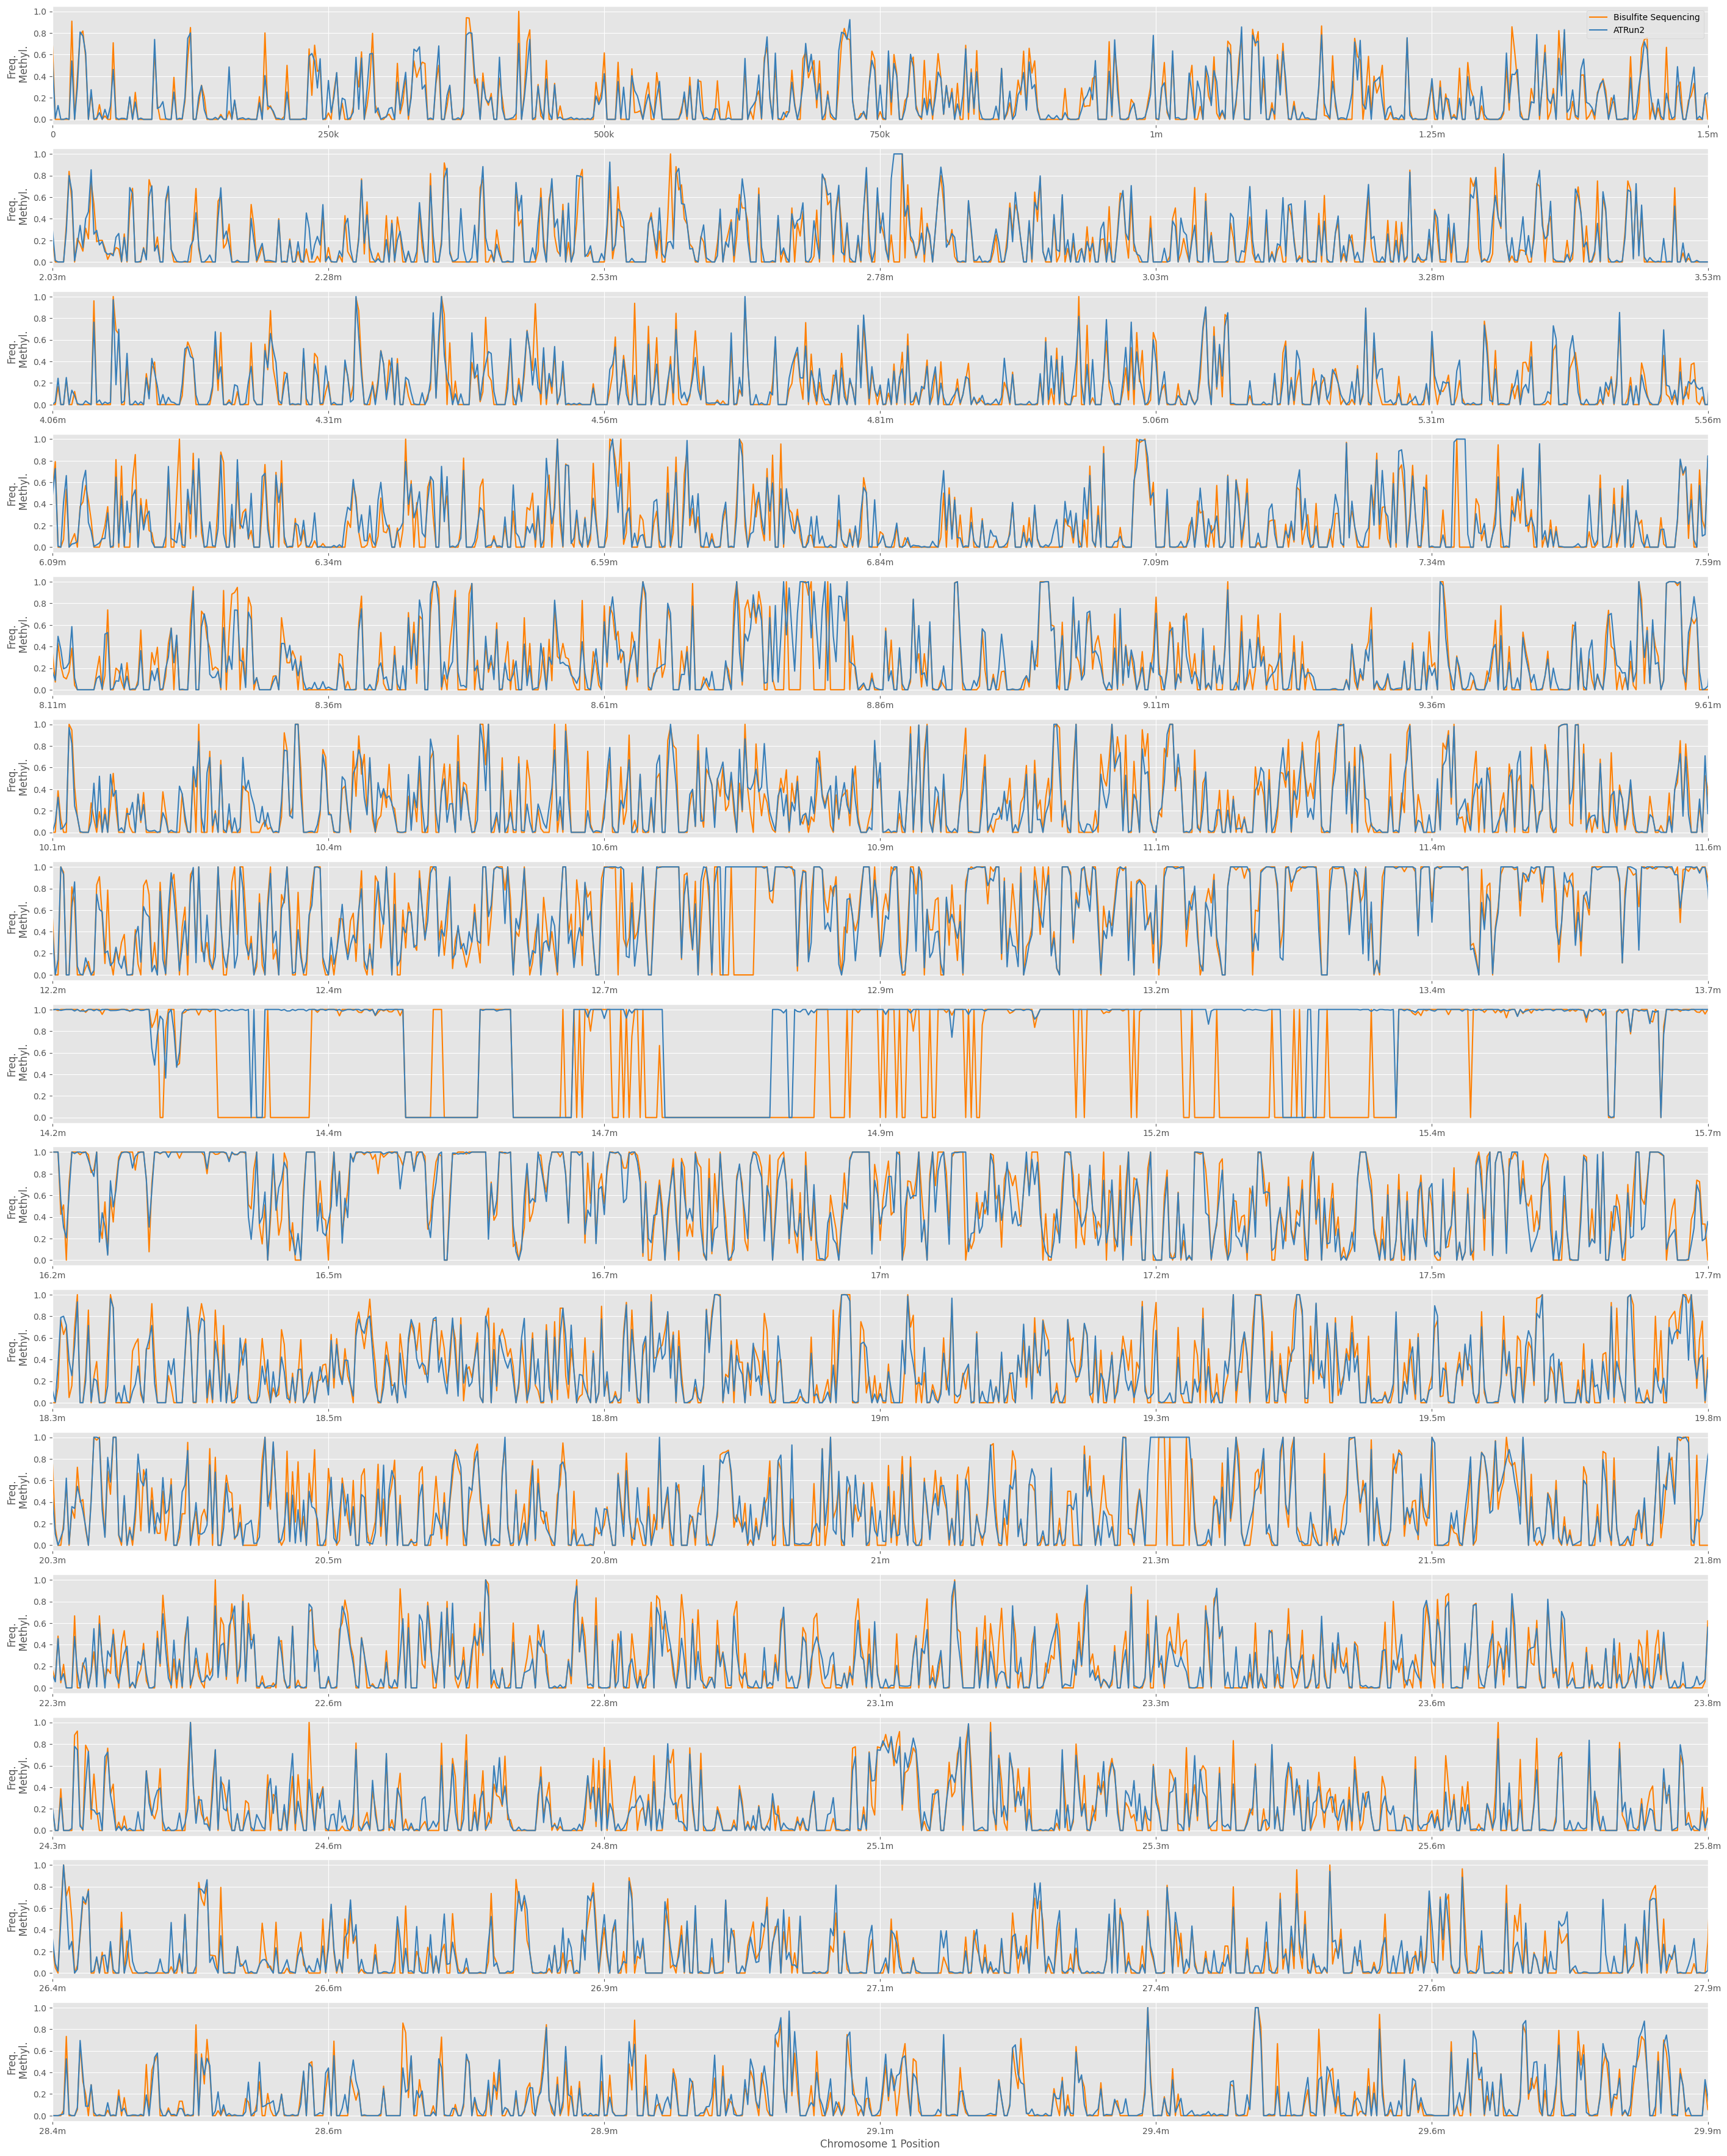

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
plt.style.use('ggplot')

colours = ["#377eb8","#ff7f00"]

def human_format(num):
    num = float('{:.3g}'.format(num))
    magnitude = 0
    while abs(num) >= 1000:
        magnitude += 1
        num /= 1000.0
    return '{}{}'.format('{:f}'.format(num).rstrip('0').rstrip('.'), ['', 'k', 'm', 'b', 't'][magnitude])

NP_methyl_chr1 = pd.read_csv("./data/methylation/ATRun2/ATRun2_CpG_5mC_chr1_counts.methylCall", delimiter='\t')
BS_methyl_chr1 = pd.read_csv("./data/methylation/BS/BS_CpG_Chr1_frac.txt", delimiter='\t')

binSize = 2500
numRows = 15
totalBins = int(NP_methyl_chr1.iloc[-1]['pos'] / binSize) + 1
row_size = int(totalBins / numRows)

minCovNP = 10
minCovBS = 8

NP_bins_methylated = [0]*totalBins
NP_bins_total = [0]*totalBins
NP_bins_prop_methylated = [0]*totalBins
for index, row in NP_methyl_chr1.iterrows():
    if row['total_bases'] >= minCovNP:
        bin_num = int(row['pos']/binSize)
        NP_bins_total[bin_num] += 1
        if row['methyl_freq'] > 0.5:
            NP_bins_methylated[bin_num] += 1

BS_bins_methylated = [0]*totalBins
BS_bins_total = [0]*totalBins
BS_bins_prop_methylated = [0]*totalBins
for index, row in BS_methyl_chr1.iterrows():
    if row['total_bases'] >= minCovBS:
        bin_num = int(row['pos']/binSize)
        BS_bins_total[bin_num] += 1
        if row['methyl_freq'] > 0.5:
            BS_bins_methylated[bin_num] += 1
        
for i in range(totalBins):
    if NP_bins_total[i] > 0:
        NP_bins_prop_methylated[i] = float(NP_bins_methylated[i]) / NP_bins_total[i]
    if BS_bins_total[i] > 0:
        BS_bins_prop_methylated[i] = float(BS_bins_methylated[i]) / BS_bins_total[i]

fig, axs, = plt.subplots(numRows, 1, figsize=(35,numRows * 3))
#plt.subplots_adjust(hspace=0.8)

for i in range(numRows):
    axs[i].plot(BS_bins_prop_methylated[(row_size * i):(row_size * (i+1))], label="Bisulfite Sequencing", color=colours[1])
    axs[i].plot(NP_bins_prop_methylated[(row_size * i):(row_size * (i+1))], label="ATRun2", color=colours[0])
    axs[i].set_ylabel("Freq.\n Methyl.")
    startTick = i * totalBins / numRows
    tickLabels=[human_format(startTick * binSize), \
                human_format((startTick + 100) * binSize),\
                human_format((startTick + 200) * binSize),\
                human_format((startTick + 300) * binSize),\
                human_format((startTick + 400) * binSize),\
                human_format((startTick + 500) * binSize),\
                human_format((startTick + 600) * binSize)]
    axs[i].set_xticks([0,100,200,300,400,500,600])
    axs[i].set_xlim(0,600)
    axs[i].set_xticklabels(tickLabels)
    #axs[i].legend(loc='center right', bbox_to_anchor=(1.15, 0.5))

axs[0].legend(loc='upper right')  
axs[-1].set_xlabel("Chromosome 1 Position")


plt.show()
fig.savefig("plots/methylation_ATRun2_chr1_track.pdf", bbox_inches='tight')

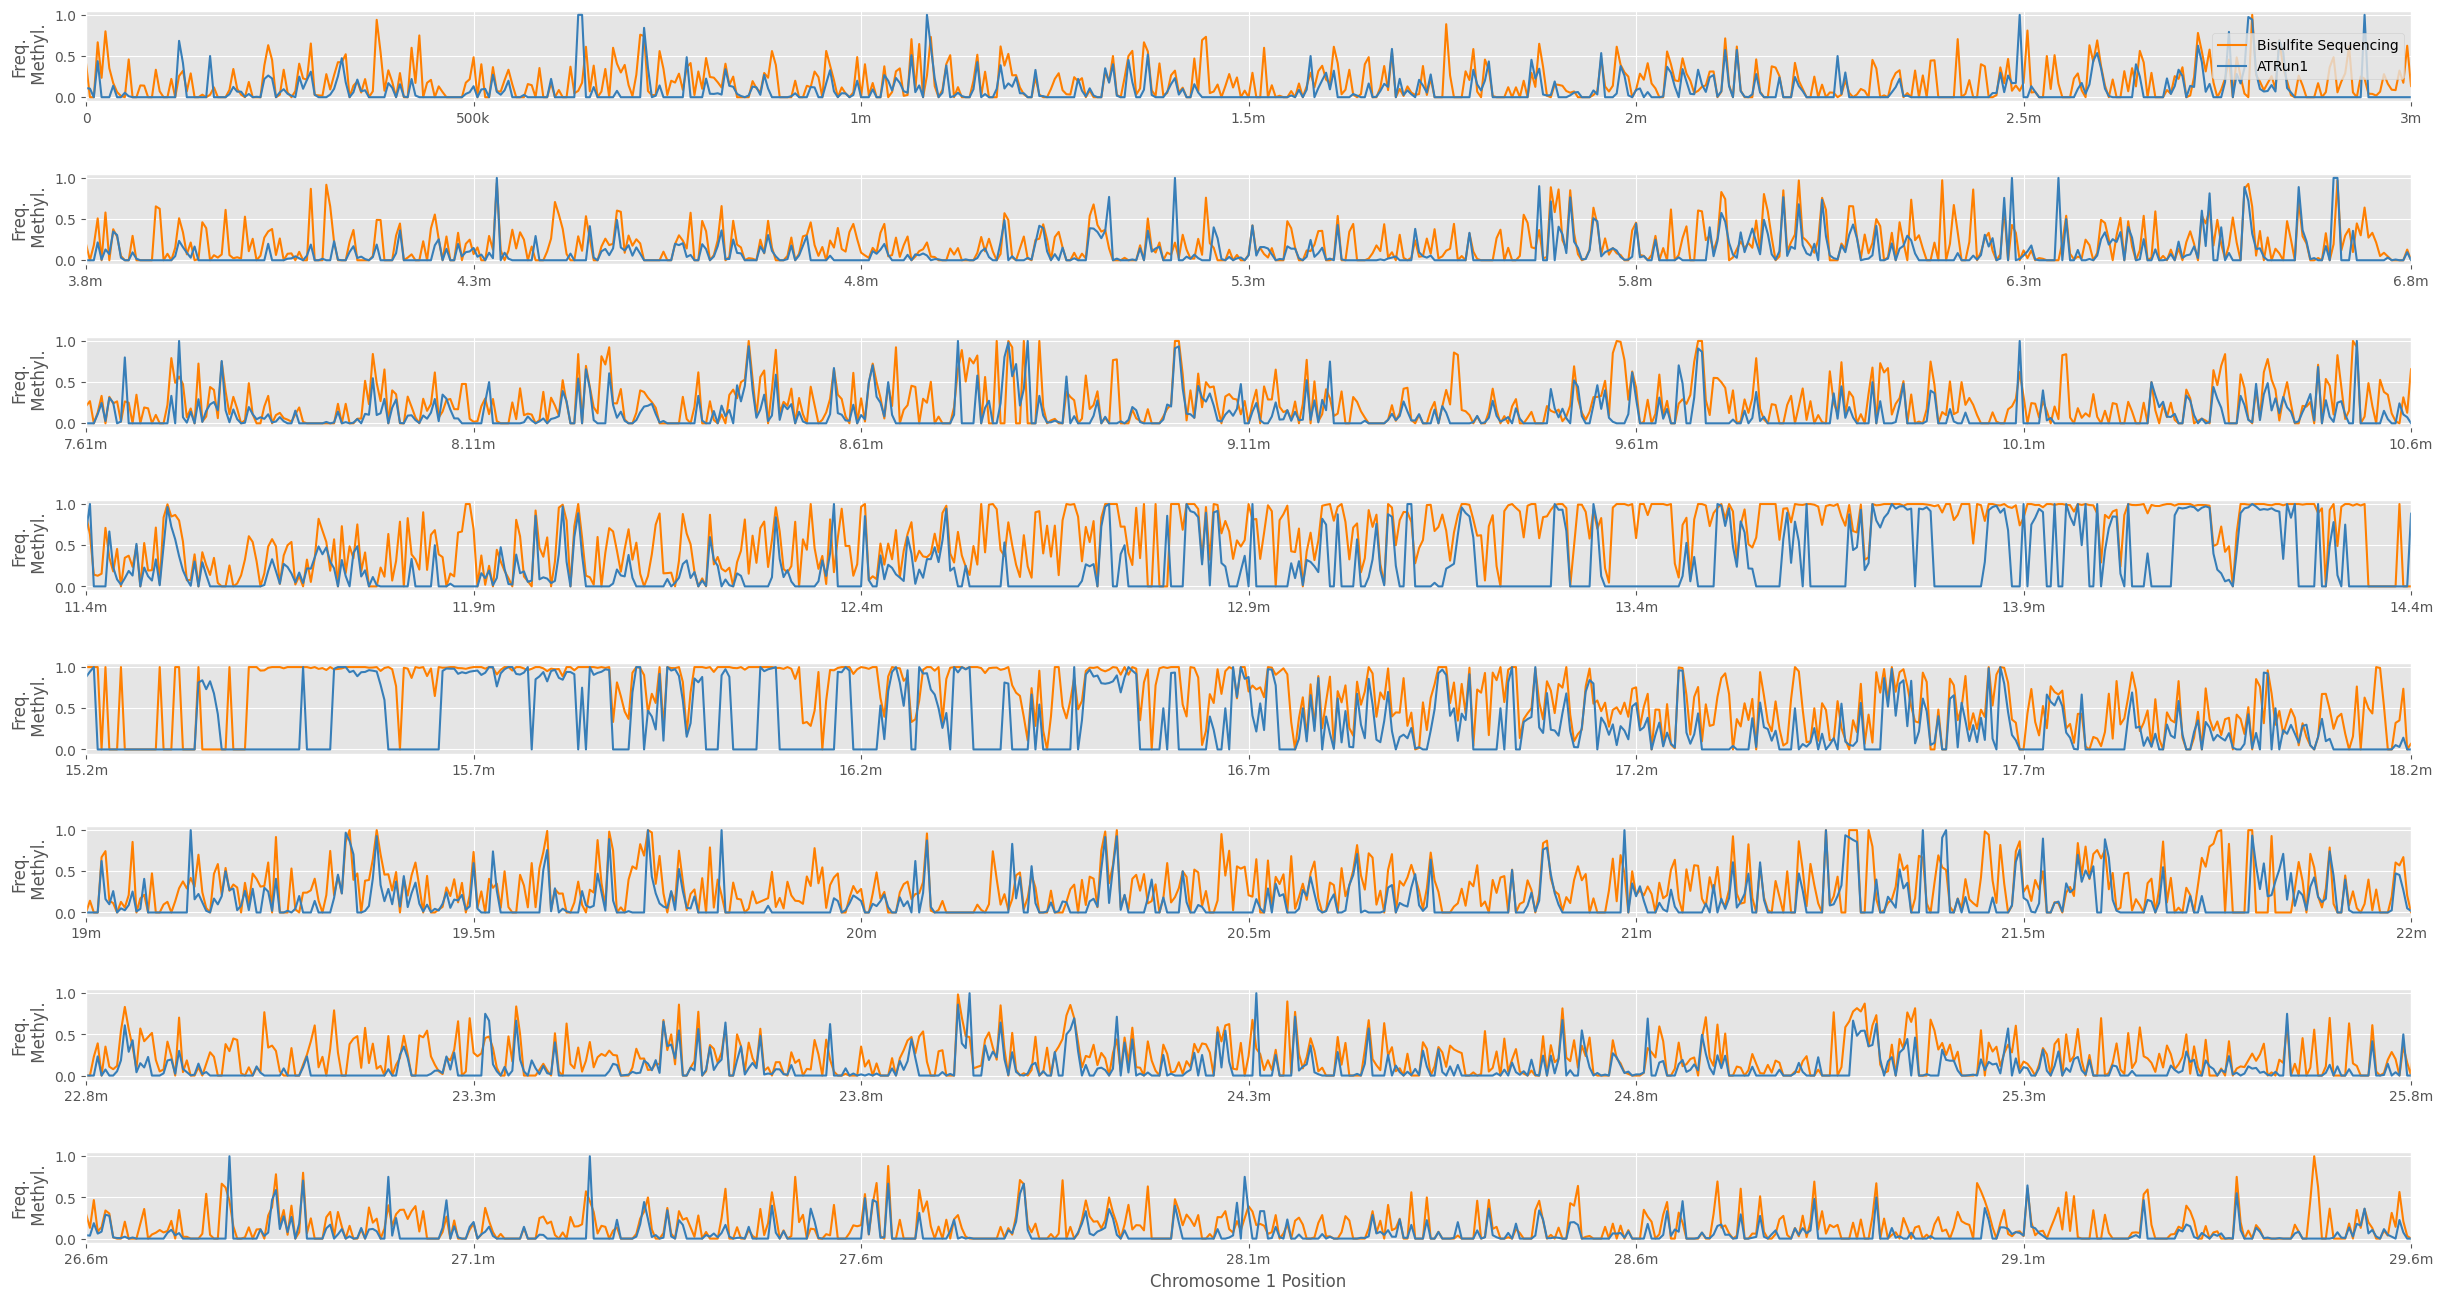

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
plt.style.use('ggplot')
colours = ["#377eb8","#ff7f00"]

def human_format(num):
    num = float('{:.3g}'.format(num))
    magnitude = 0
    while abs(num) >= 1000:
        magnitude += 1
        num /= 1000.0
    return '{}{}'.format('{:f}'.format(num).rstrip('0').rstrip('.'), ['', 'k', 'm', 'b', 't'][magnitude])

NP_methyl_chr1 = pd.read_csv("./data/methylation/ATRun1/ATRun1_CpG_5mC_counts_Chr1.methylCall", delimiter='\t')
BS_methyl_chr1 = pd.read_csv("./data/methylation/BS/BS_CpG_Chr1_frac.txt", delimiter='\t')

binSize = 5000
numRows = 8
totalBins = int(NP_methyl_chr1.iloc[-1]['pos'] / binSize) + 1
row_size = int(totalBins / numRows)

minCovNP = 10
minCovBS = 8

NP_bins_methylated = [0]*totalBins
NP_bins_total = [0]*totalBins
NP_bins_prop_methylated = [0]*totalBins
for index, row in NP_methyl_chr1.iterrows():
    if row['total_bases'] >= minCovNP:
        bin_num = int(row['pos']/binSize)
        NP_bins_total[bin_num] += 1
        if row['methyl_freq'] > 0.5:
            NP_bins_methylated[bin_num] += 1

BS_bins_methylated = [0]*totalBins
BS_bins_total = [0]*totalBins
BS_bins_prop_methylated = [0]*totalBins
for index, row in BS_methyl_chr1.iterrows():
    if row['total_bases'] >= minCovBS:
        bin_num = int(row['pos']/binSize)
        BS_bins_total[bin_num] += 1
        if row['methyl_freq'] > 0.5:
            BS_bins_methylated[bin_num] += 1
        
for i in range(totalBins):
    if NP_bins_total[i] > 0:
        NP_bins_prop_methylated[i] = float(NP_bins_methylated[i]) / NP_bins_total[i]
    if BS_bins_total[i] > 0:
        BS_bins_prop_methylated[i] = float(BS_bins_methylated[i]) / BS_bins_total[i]

fig, axs, = plt.subplots(numRows, 1, figsize=(30,numRows * 2))
plt.subplots_adjust(hspace=0.8)

for i in range(numRows):
    axs[i].plot(BS_bins_prop_methylated[(row_size * i):(row_size * (i+1))], label="Bisulfite Sequencing", color=colours[1])
    axs[i].plot(NP_bins_prop_methylated[(row_size * i):(row_size * (i+1))], label="ATRun1", color=colours[0])
    axs[i].set_ylabel("Freq.\n Methyl.")
    startTick = i * totalBins / numRows
    tickLabels=[human_format(startTick * binSize), \
                human_format((startTick + 100) * binSize),\
                human_format((startTick + 200) * binSize),\
                human_format((startTick + 300) * binSize),\
                human_format((startTick + 400) * binSize),\
                human_format((startTick + 500) * binSize),\
                human_format((startTick + 600) * binSize)]
    axs[i].set_xticks([0,100,200,300,400,500,600])
    axs[i].set_xlim(0,600)
    axs[i].set_xticklabels(tickLabels)
   # axs[i].legend(loc='center right', bbox_to_anchor=(1.15, 0.5))

axs[0].legend(loc='center right')   
axs[-1].set_xlabel("Chromosome 1 Position")


plt.show()
fig.savefig("plots/methylation_ATRun1_chr1_track.pdf", bbox_inches='tight')

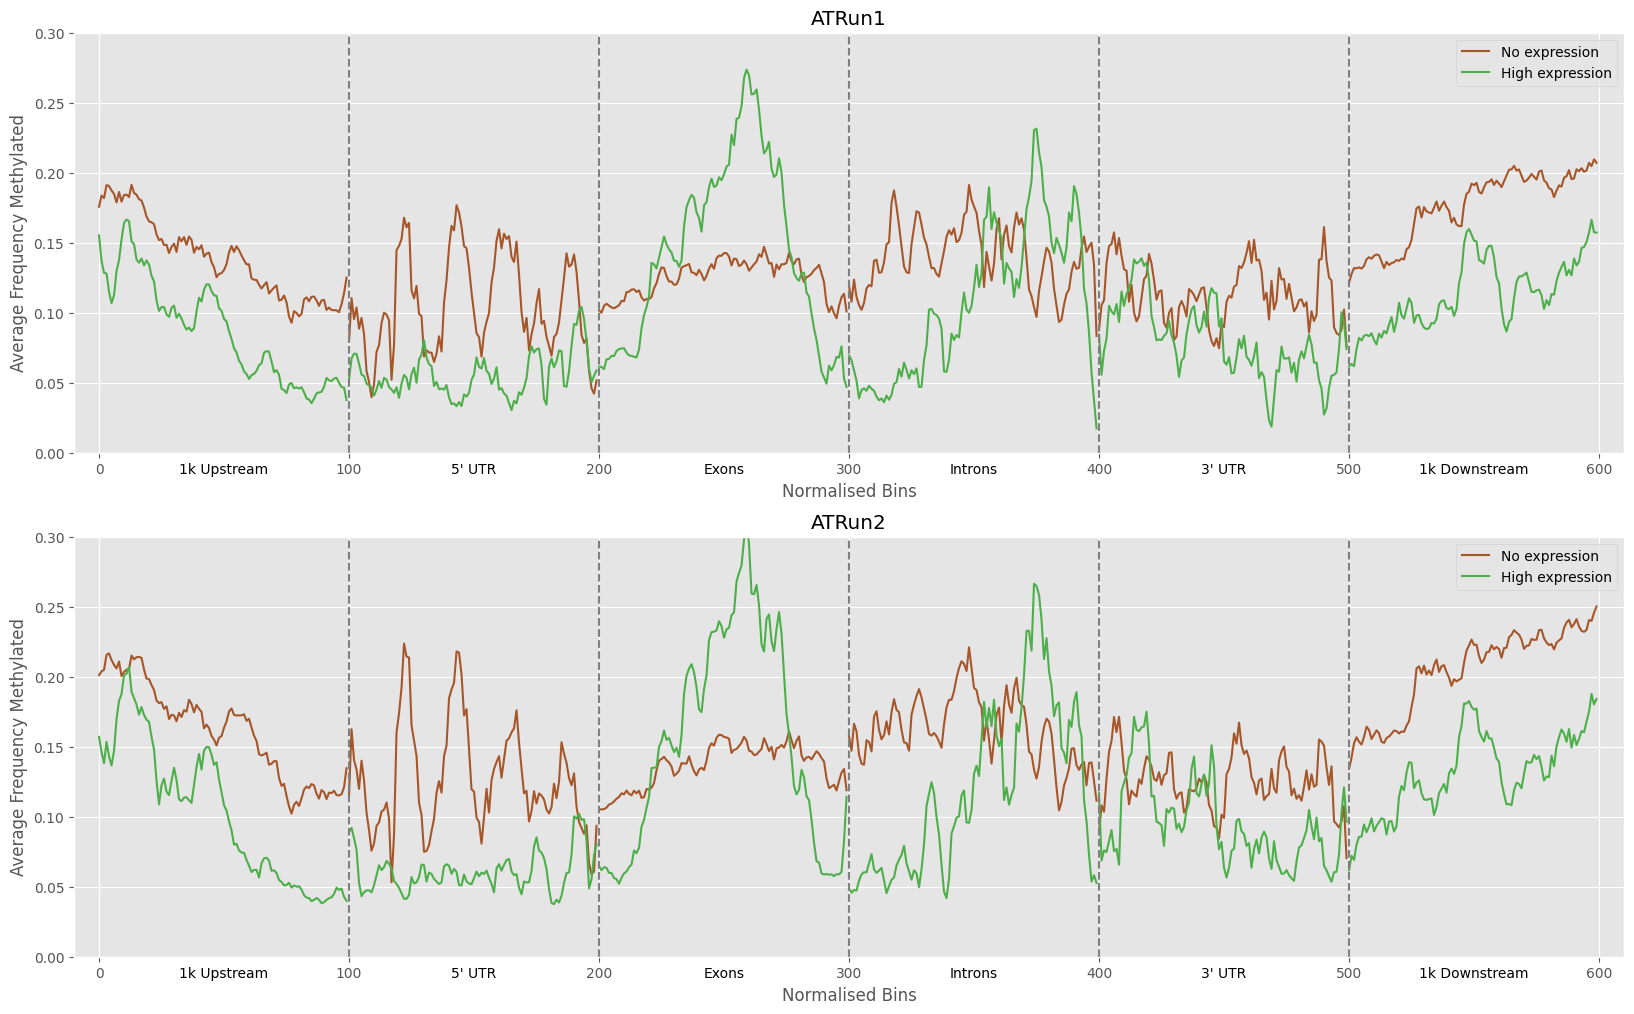

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
plt.style.use('ggplot')
colours = ["#4daf4a","#a65629"]

ATRun1_meth_1k_upstream_high = pd.read_csv("./data/methylation/genes/hists_ATRun1_high_expression/ATRun1_1k_upstream_meth_leaf_high.hist", delimiter='\t', names=["bin","freq"])
ATRun1_meth_1k_downstream_high = pd.read_csv("./data/methylation/genes/hists_ATRun1_high_expression/ATRun1_1k_downstream_meth_leaf_high.hist", delimiter='\t', names=["bin","freq"])
ATRun1_meth_3_utr_high = pd.read_csv("./data/methylation/genes/hists_ATRun1_high_expression/ATRun1_3_utr_meth_leaf_high.hist", delimiter='\t', names=["bin","freq"])
ATRun1_meth_5_utr_high = pd.read_csv("./data/methylation/genes/hists_ATRun1_high_expression/ATRun1_5_utr_meth_leaf_high.hist", delimiter='\t', names=["bin","freq"])
ATRun1_meth_exon_high = pd.read_csv("./data/methylation/genes/hists_ATRun1_high_expression/ATRun1_exon_meth_leaf_high.hist", delimiter='\t', names=["bin","freq"])
ATRun1_meth_intron_high = pd.read_csv("./data/methylation/genes/hists_ATRun1_high_expression/ATRun1_intron_meth_leaf_high.hist", delimiter='\t', names=["bin","freq"])

ATRun1_meth_1k_upstream_no_expression = pd.read_csv("./data/methylation/genes/hists_ATRun1_no_expression/ATRun1_1k_upstream_meth_leaf_no_expression.hist", delimiter='\t', names=["bin","freq"])
ATRun1_meth_1k_downstream_no_expression = pd.read_csv("./data/methylation/genes/hists_ATRun1_no_expression/ATRun1_1k_downstream_meth_leaf_no_expression.hist", delimiter='\t', names=["bin","freq"])
ATRun1_meth_3_utr_no_expression = pd.read_csv("./data/methylation/genes/hists_ATRun1_no_expression/ATRun1_3_utr_meth_leaf_no_expression.hist", delimiter='\t', names=["bin","freq"])
ATRun1_meth_5_utr_no_expression = pd.read_csv("./data/methylation/genes/hists_ATRun1_no_expression/ATRun1_5_utr_meth_leaf_no_expression.hist", delimiter='\t', names=["bin","freq"])
ATRun1_meth_exon_no_expression = pd.read_csv("./data/methylation/genes/hists_ATRun1_no_expression/ATRun1_exon_meth_leaf_no_expression.hist", delimiter='\t', names=["bin","freq"])
ATRun1_meth_intron_no_expression = pd.read_csv("./data/methylation/genes/hists_ATRun1_no_expression/ATRun1_intron_meth_leaf_no_expression.hist", delimiter='\t', names=["bin","freq"])

ATRun2_meth_1k_upstream_high = pd.read_csv("./data/methylation/genes/hists_ATRun2_high_expression/ATRun2_1k_upstream_meth_leaf_high.hist", delimiter='\t', names=["bin","freq"])
ATRun2_meth_1k_downstream_high = pd.read_csv("./data/methylation/genes/hists_ATRun2_high_expression/ATRun2_1k_downstream_meth_leaf_high.hist", delimiter='\t', names=["bin","freq"])
ATRun2_meth_3_utr_high = pd.read_csv("./data/methylation/genes/hists_ATRun2_high_expression/ATRun2_3_utr_meth_leaf_high.hist", delimiter='\t', names=["bin","freq"])
ATRun2_meth_5_utr_high = pd.read_csv("./data/methylation/genes/hists_ATRun2_high_expression/ATRun2_5_utr_meth_leaf_high.hist", delimiter='\t', names=["bin","freq"])
ATRun2_meth_exon_high = pd.read_csv("./data/methylation/genes/hists_ATRun2_high_expression/ATRun2_exon_meth_leaf_high.hist", delimiter='\t', names=["bin","freq"])
ATRun2_meth_intron_high = pd.read_csv("./data/methylation/genes/hists_ATRun2_high_expression/ATRun2_intron_meth_leaf_high.hist", delimiter='\t', names=["bin","freq"])

ATRun2_meth_1k_upstream_no_expression = pd.read_csv("./data/methylation/genes/hists_ATRun2_no_expression/ATRun2_1k_upstream_meth_leaf_no_expression.hist", delimiter='\t', names=["bin","freq"])
ATRun2_meth_1k_downstream_no_expression = pd.read_csv("./data/methylation/genes/hists_ATRun2_no_expression/ATRun2_1k_downstream_meth_leaf_no_expression.hist", delimiter='\t', names=["bin","freq"])
ATRun2_meth_3_utr_no_expression = pd.read_csv("./data/methylation/genes/hists_ATRun2_no_expression/ATRun2_3_utr_meth_leaf_no_expression.hist", delimiter='\t', names=["bin","freq"])
ATRun2_meth_5_utr_no_expression = pd.read_csv("./data/methylation/genes/hists_ATRun2_no_expression/ATRun2_5_utr_meth_leaf_no_expression.hist", delimiter='\t', names=["bin","freq"])
ATRun2_meth_exon_no_expression = pd.read_csv("./data/methylation/genes/hists_ATRun2_no_expression/ATRun2_exon_meth_leaf_no_expression.hist", delimiter='\t', names=["bin","freq"])
ATRun2_meth_intron_no_expression = pd.read_csv("./data/methylation/genes/hists_ATRun2_no_expression/ATRun2_intron_meth_leaf_no_expression.hist", delimiter='\t', names=["bin","freq"])

fig, axs = plt.subplots(2, 1, figsize=(20,12))
axs[0].plot(ATRun1_meth_1k_upstream_no_expression["bin"], ATRun1_meth_1k_upstream_no_expression["freq"], label="No expression", color=colours[1])
axs[0].plot(ATRun1_meth_5_utr_no_expression["bin"]+100, ATRun1_meth_5_utr_no_expression["freq"], color=colours[1])
axs[0].plot(ATRun1_meth_exon_no_expression["bin"]+200, ATRun1_meth_exon_no_expression["freq"], color=colours[1])
axs[0].plot(ATRun1_meth_intron_no_expression["bin"]+300, ATRun1_meth_intron_no_expression["freq"], color=colours[1])
axs[0].plot(ATRun1_meth_3_utr_no_expression["bin"]+400, ATRun1_meth_3_utr_no_expression["freq"], color=colours[1])
axs[0].plot(ATRun1_meth_1k_downstream_no_expression["bin"]+500, ATRun1_meth_1k_downstream_no_expression["freq"], color=colours[1])
axs[0].plot(ATRun1_meth_1k_upstream_high["bin"], ATRun1_meth_1k_upstream_high["freq"], label="High expression", color=colours[0])
axs[0].plot(ATRun1_meth_5_utr_high["bin"]+100, ATRun1_meth_5_utr_high["freq"], color=colours[0])
axs[0].plot(ATRun1_meth_exon_high["bin"]+200, ATRun1_meth_exon_high["freq"], color=colours[0])
axs[0].plot(ATRun1_meth_intron_high["bin"]+300, ATRun1_meth_intron_high["freq"], color=colours[0])
axs[0].plot(ATRun1_meth_3_utr_high["bin"]+400, ATRun1_meth_3_utr_high["freq"], color=colours[0])
axs[0].plot(ATRun1_meth_1k_downstream_high["bin"]+500, ATRun1_meth_1k_downstream_high["freq"], color=colours[0])

axs[1].plot(ATRun2_meth_1k_upstream_no_expression["bin"], ATRun2_meth_1k_upstream_no_expression["freq"], label="No expression", color=colours[1])
axs[1].plot(ATRun2_meth_5_utr_no_expression["bin"]+100, ATRun2_meth_5_utr_no_expression["freq"], color=colours[1])
axs[1].plot(ATRun2_meth_exon_no_expression["bin"]+200, ATRun2_meth_exon_no_expression["freq"], color=colours[1])
axs[1].plot(ATRun2_meth_intron_no_expression["bin"]+300, ATRun2_meth_intron_no_expression["freq"], color=colours[1])
axs[1].plot(ATRun2_meth_3_utr_no_expression["bin"]+400, ATRun2_meth_3_utr_no_expression["freq"], color=colours[1])
axs[1].plot(ATRun2_meth_1k_downstream_no_expression["bin"]+500, ATRun2_meth_1k_downstream_no_expression["freq"], color=colours[1])
axs[1].plot(ATRun2_meth_1k_upstream_high["bin"], ATRun2_meth_1k_upstream_high["freq"], label="High expression", color=colours[0])
axs[1].plot(ATRun2_meth_5_utr_high["bin"]+100, ATRun2_meth_5_utr_high["freq"], color=colours[0])
axs[1].plot(ATRun2_meth_exon_high["bin"]+200, ATRun2_meth_exon_high["freq"], color=colours[0])
axs[1].plot(ATRun2_meth_intron_high["bin"]+300, ATRun2_meth_intron_high["freq"], color=colours[0])
axs[1].plot(ATRun2_meth_3_utr_high["bin"]+400, ATRun2_meth_3_utr_high["freq"], color=colours[0])
axs[1].plot(ATRun2_meth_1k_downstream_high["bin"]+500, ATRun2_meth_1k_downstream_high["freq"], color=colours[0])

for ax in axs:
    ax.text( 50, -0.015, "1k Upstream", ha='center')
    ax.text( 150, -0.015, "5' UTR", ha='center')
    ax.text( 250, -0.015, "Exons", ha='center')
    ax.text( 350, -0.015, "Introns", ha='center')
    ax.text( 450, -0.015, "3' UTR", ha='center')
    ax.text( 550, -0.015, "1k Downstream", ha='center')
    
    for i in [1,2,3,4,5]:
        ax.axvline(x=i*100, color='gray', linestyle='--')

    ax.set_xlabel("Normalised Bins")
    ax.set_ylabel("Average Frequency Methylated")
    ax.set_xlim(-10,610)
    ax.set_ylim(0,0.3)
    ax.legend()


axs[0].set_title("ATRun1")
axs[1].set_title("ATRun2")
plt.show()
fig.savefig("plots/gene_methylation.pdf", bbox_inches='tight')